In [1]:
import numpy as np

import os

from nbodykit.lab import *
from nbodykit import setup_logging, style

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

In [2]:
from baryonification.baryonification.params import par
from baryonification.baryonification.cosmo import cosmo
from baryonification.baryonification.displ import displace
from baryonification.baryonification.halo_displ import displace_haloes

from miniramses.utils.py.miniramses import rd_info
from miniramses.utils.py.miniramses import Info

In [3]:
#initialise parameters

par = par()

if par.code.multicomp:
    comp = 'multicomp' #'multicomp' or 'singlecomp'
else:
    comp = 'singlecomp'

size = par.code.size #'big' or 'small'

par.files.transfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/CDM_PLANCK_tk.dat"
par.files.cosmofct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/cosmofct.dat"
par.files.displfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/displfct.dat"
par.files.halofile_format = "ramses"
par.files.partfile_format = "ramses"
if size == 'big':
    par.files.partfile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
    par.files.halofile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
elif size == 'small':
    par.files.halofile_in = "/home/jamesdr/scratch/smallbox/output_00011"
    par.files.partfile_in = "/home/jamesdr/scratch/smallbox/output_00011"
par.files.partfile_out = "/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size)
par.files.halofile_out = "/home/jamesdr/usrp2024/{}_{}/halofile_out.std".format(comp,size)

Found 2097152 particles


In [4]:
import re

# Extracting the path using regular expression
path = re.match(r'(.*/{}box/)'.format(size), par.files.partfile_in).group(1)

# Extracting the number as an integer
nout = int(re.match(r'.*/output_(\d+)', par.files.partfile_in).group(1))

i = rd_info(nout, path=path)
unit_l = i.unit_l
unit_d = i.unit_d #g/cm^3
unit_m = unit_d * (unit_l)**3.0
unit_m_in_Msol_per_h = unit_m / (1.989e33) * par.cosmo.h0
unit_l_in_Mpc_per_h = unit_l / (3.086e24) * par.cosmo.h0

In [5]:
from baryonification.baryonification.io import read_nbody_file

In [6]:
p_header, non_displaced_particles = read_nbody_file(par)

Found 2097152 particles


In [7]:
cosmo(par);

Normalizing power-spectrum done!


In [8]:
displace(par);

Found 2097152 particles
Found 2226 clumps
Converting r200b, M200b, and c200b to r200c, M200c, and c200c


/home/jamesdr/.conda/envs/usrp2024/lib/python3.8/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Done!
N_cpu =  1
building tree..
...done!
Om =  0.9041445
Total number of star particles 0


In [9]:
if comp == 'multicomp':
    def read_displaced_particles(file):

        Lbox   = unit_l / (3.086e24) * par.cosmo.h0
        N_chunk = 1
        L_chunk = Lbox/N_chunk
    
        Om = i.omega_m
        z  = par.cosmo.z
    
        f = open(file, 'r')

        #header
        p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
        p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
        #gas
        p_gas_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                               ('vz', '>f4'),('rho','>f4'),('temp','>f4'),('hsmooth','>f4'),('metals','>f4'),('phi','>f4')])
        p_gas = np.fromfile(f, dtype=p_gas_dt, count=int(p_header['Ngas']), sep='')
    
        #dm
        p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
        p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')
    
        #stars
        p_star_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                                 ('vz', '>f4'),('metals','>f4'),('tform','>f4'),('eps','>f4'),('phi','>f4')])
        p_star = np.fromfile(f, dtype=p_star_dt, count=int(p_header['Nstar']), sep='')

        #convert to Mpc/h
        p_gas['x']=Lbox*(p_gas['x']+0.5)
        p_gas['y']=Lbox*(p_gas['y']+0.5)
        p_gas['z']=Lbox*(p_gas['z']+0.5)
        p_dm['x']=Lbox*(p_dm['x']+0.5)
        p_dm['y']=Lbox*(p_dm['y']+0.5)
        p_dm['z']=Lbox*(p_dm['z']+0.5)
        p_star['x']=Lbox*(p_star['x']+0.5)
        p_star['y']=Lbox*(p_star['y']+0.5)
        p_star['z']=Lbox*(p_star['z']+0.5)

        #convert to Mstar/h
        print("Om = ", np.sum(p_gas['mass'])+np.sum(p_dm['mass'])+np.sum(p_star['mass']))
        p_gas['mass'] = p_gas['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        p_star['mass'] = p_star['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
        print('Reading tipsy-file done!')
    
        #split particles into chunks
        p_gas_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_gas = np.where((p_gas['x']>=x_min) & (p_gas['x']<x_max) & (p_gas['y']>=y_min) & (p_gas['y']<y_max) & (p_gas['z']>=z_min) & (p_gas['z']<z_max))
                    p_gas_list += [p_gas[ID_gas]]
                
        #split particles into chunks
        p_dm_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                    p_dm_list += [p_dm[ID_dm]]
                
        #split particles into chunks
        p_star_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_star = np.where((p_star['x']>=x_min) & (p_star['x']<x_max) & (p_star['y']>=y_min) & (p_star['y']<y_max) & (p_star['z']>=z_min) & (p_star['z']<z_max))
                    p_star_list += [p_star[ID_star]]
   
        pl = 0
        for pp in p_gas_list:
            pl += len(pp)
        if (pl != len(p_gas)):
            print('Chunking: particle number not conserved! Exit.')
            exit()

        pl = 0
        for pp in p_dm_list:
            pl += len(pp)
        if (pl != len(p_dm)):
            print('Chunking: particle number not conserved! Exit.')
            exit()
    
        pl = 0
        for pp in p_star_list:
            pl += len(pp)
        if (pl != len(p_star)):
            print('Chunking: particle number not conserved! Exit.')
            exit()
    
        return p_header, p_gas_list, p_dm_list, p_star_list
    
elif comp == 'singlecomp':
    def read_displaced_particles(file):

        Lbox   = unit_l / (3.086e24) * par.cosmo.h0
        N_chunk = 1
        L_chunk = Lbox/N_chunk
    
        Om = i.omega_m
        z  = par.cosmo.z
    
        f = open(file, 'r')

        #header
        p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
        p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
        #dm
        p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
        p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')

        #convert to Mpc/h
        p_dm['x']=Lbox*(p_dm['x']+0.5)
        p_dm['y']=Lbox*(p_dm['y']+0.5)
        p_dm['z']=Lbox*(p_dm['z']+0.5)

        #convert to Mstar/h
        print("Om = ", np.sum(p_dm['mass']))
        p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
        print('Reading tipsy-file done!')
                
        #split particles into chunks
        p_dm_list   = []
        for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            x_max = x_min + L_chunk
            if (x_max == Lbox):
                x_max = 1.00001*x_max
            for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                y_max =y_min + L_chunk
                if (y_max == Lbox):
                        y_max = 1.00001*y_max
                for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                    z_max = z_min + L_chunk
                    if (z_max == Lbox):
                            z_max = 1.00001*z_max
                    ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                    p_dm_list += [p_dm[ID_dm]]
   
        pl = 0
        for pp in p_dm_list:
            pl += len(pp)
        if (pl != len(p_dm)):
            print('Chunking: particle number not conserved! Exit.')
            exit()
    
        return p_header, p_dm_list

In [10]:
if comp=='multicomp':    
    p_displaced_header, displaced_gas, displaced_dm, displaced_stars = read_displaced_particles("/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size))
elif comp=='singlecomp':
    p_displaced_header, displaced_dm = read_displaced_particles("/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size))

Om =  0.9041445
Reading tipsy-file done!


In [11]:
plt.style.use(style.notebook)

In [12]:
setup_logging()

In [13]:
if comp=='multicomp':
    DMO = ArrayCatalog({'Position' : np.vstack((non_displaced_particles[0]['x'],non_displaced_particles[0]['y'],non_displaced_particles[0]['z'])).T})

    DM = ArrayCatalog({'Position' : np.vstack((displaced_dm[0]['x'],displaced_dm[0]['y'],displaced_dm[0]['z'])).T})
    gas = ArrayCatalog({'Position' : np.vstack((displaced_gas[0]['x'],displaced_gas[0]['y'],displaced_gas[0]['z'])).T})
    star = ArrayCatalog({'Position' : np.vstack((displaced_stars[0]['x'],displaced_stars[0]['y'],displaced_stars[0]['z'])).T})

    DMO['Mass'] = 1.0
    DM['Mass'] = displaced_dm[0]['mass'][0]/(displaced_dm[0]['mass'][0] + displaced_gas[0]['mass'][0] + displaced_stars[0]['mass'][0])
    gas['Mass'] = displaced_gas[0]['mass'][0]/(displaced_dm[0]['mass'][0] + displaced_gas[0]['mass'][0] + displaced_stars[0]['mass'][0])
    star['Mass'] = displaced_stars[0]['mass'][0]/(displaced_dm[0]['mass'][0] + displaced_gas[0]['mass'][0] + displaced_stars[0]['mass'][0])

    m_DMO = DMO['Mass']
    m_DM = DM['Mass']
    m_gas = gas['Mass']
    m_star = star['Mass']

    combined = MultipleSpeciesCatalog(['DM', 'gas', 'star'], DM, gas, star)
elif comp=='singlecomp':
    DMO = ArrayCatalog({'Position' : np.vstack((non_displaced_particles[0]['x'],non_displaced_particles[0]['y'],non_displaced_particles[0]['z'])).T})

    DM = ArrayCatalog({'Position' : np.vstack((displaced_dm[0]['x'],displaced_dm[0]['y'],displaced_dm[0]['z'])).T})
    
    DMO['Mass'] = 1.0
    DM['Mass'] = 1.0
    
    m_DMO = DMO['Mass']
    m_DM = DM['Mass']

In [14]:
if comp=='multicomp': #Normally Nmesh=2048
    DMO_mesh = DMO.to_mesh(resampler='tsc', Nmesh=2048, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')

    combined_mesh = combined.to_mesh(resampler='tsc', Nmesh=2048, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')
elif comp=='singlecomp':
    DMO_mesh = DMO.to_mesh(resampler='tsc', Nmesh=2048, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')

    DM_mesh = DM.to_mesh(resampler='tsc', Nmesh=2048, BoxSize=unit_l_in_Mpc_per_h, compensated=True, position='Position', weight='Mass')

In [15]:
if comp=='multicomp':
    r_DMO = FFTPower(DMO_mesh, mode='1d', dk=0.05, kmin=0.05) #Normally 0.05

    r_combined = FFTPower(combined_mesh, mode='1d', dk=0.05, kmin=0.05)
elif comp=='singlecomp':
    r_DMO = FFTPower(DMO_mesh, mode='1d', dk=0.05, kmin=0.05)

    r_DM = FFTPower(DM_mesh, mode='1d', dk=0.05, kmin=0.05)

[ 000008.12 ]   0: 03-30 17:56  CatalogMesh     INFO     Chunk 0 ~ 4194304 / 2097152 
[ 000009.78 ]   0: 03-30 17:56  CatalogMesh     INFO     painted 2097152 out of 2097152 objects to mesh
[ 000013.51 ]   0: 03-30 17:57  CatalogMesh     INFO     painted 2097152 out of 2097152 objects to mesh
[ 000013.51 ]   0: 03-30 17:57  CatalogMesh     INFO     mean particles per cell is 0.000244141
[ 000013.51 ]   0: 03-30 17:57  CatalogMesh     INFO     sum is 2.09715e+06 
[ 000020.06 ]   0: 03-30 17:57  CatalogMesh     INFO     normalized the convention to 1 + delta
[ 000173.20 ]   0: 03-30 17:59  CatalogMesh     INFO     field: (ArrayCatalog(size=2097152) as CatalogMesh) painting done
[ 000532.92 ]   0: 03-30 18:05  CatalogMesh     INFO     Chunk 0 ~ 4194304 / 2097152 
[ 000534.43 ]   0: 03-30 18:05  CatalogMesh     INFO     painted 2097152 out of 2097152 objects to mesh
[ 000538.16 ]   0: 03-30 18:05  CatalogMesh     INFO     painted 2097152 out of 2097152 objects to mesh
[ 000538.16 ]   0: 03

In [16]:
if comp=='multicomp':
    Pk_DMO = r_DMO.power

    Pk_combined = r_combined.power
elif comp=='singlecomp':
    Pk_DMO = r_DMO.power

    Pk_DM = r_DM.power

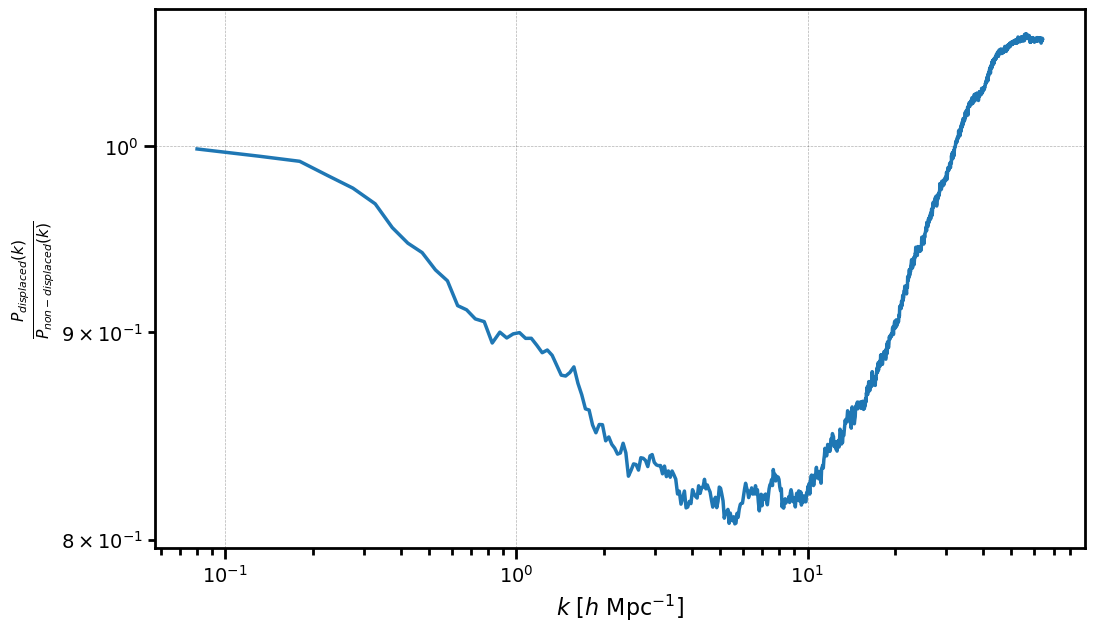

In [17]:
if comp=='multicomp':
    ratio = (Pk_combined['power'].real)/(Pk_DMO['power'].real)
elif comp=='singlecomp':
    ratio = (Pk_DM['power'].real)/(Pk_DMO['power'].real)
# print the shot noise subtracted P(k)
plt.loglog(Pk_DMO['k'], ratio);

# format the axes
plt.xlabel(r"$k$ [$h \ \mathrm{Mpc}^{-1}$]");
plt.ylabel(r"$\frac{P_{displaced}(k)}{P_{non-displaced}(k)}$");

In [18]:
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'k_z=2.0.npy'), Pk_DMO['k'])
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'ratio_z=2.0.npy'), ratio)